In [1]:
# Импорт библиотек
import os
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt

RANDOM_STATE = 42

# Папки проекта 
PROJECT_DIR = Path(".")
DATA_PATH = PROJECT_DIR / "S05-hw-dataset.csv"
FIGURES_DIR = PROJECT_DIR / "figures"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

WindowsPath('S05-hw-dataset.csv')

In [2]:
# Загрузка данных
df = pd.read_csv(DATA_PATH)

df.head()

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1


In [3]:
# Информация о столбцах и типах
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk_score               30

In [4]:
# Базовые статистики по числовым признакам
df.describe().T

,count,mean,std,min,25%,50%,75%,max
client_id,3000.0,1500.500000,866.169729,1.000000,750.750000,1500.500000,2250.250000,3000.000000
age,3000.0,45.059667,14.192883,21.000000,33.000000,45.000000,57.000000,69.000000
income,3000.0,69658.992000,24742.235182,15000.000000,52641.750000,69784.500000,85874.250000,156351.000000
years_employed,3000.0,19.577667,11.381497,0.000000,10.000000,20.000000,29.000000,39.000000
credit_score,3000.0,649.285333,69.955852,402.000000,604.000000,647.000000,697.000000,850.000000
debt_to_income,3000.0,0.284065,0.161112,0.006147,0.157796,0.261726,0.388886,0.878343
num_credit_cards,3000.0,3.494667,2.289917,0.000000,1.000000,3.000000,6.000000,7.000000
num_late_payments,3000.0,6.869333,4.291278,0.000000,3.000000,7.000000,10.000000,14.000000
has_mortgage,3000.0,0.495000,0.500058,0.000000,0.000000,0.000000,1.000000,1.000000
has_car_loan,3000.0,0.501333,0.500082,0.000000,0.000000,1.000000,1.000000,1.000000


In [5]:
# Распределение таргета (default)
target_dist = df["default"].value_counts(dropna=False)
target_dist_norm = df["default"].value_counts(normalize=True, dropna=False)

print("Counts:")
display(target_dist)

print("\nNormalized:")
display(target_dist_norm)

Counts:


default
0    1769
1    1231
Name: count, dtype: int64


Normalized:


default
0    0.589667
1    0.410333
Name: proportion, dtype: float64

Датасет: 3000 строк, 17 столбцов. Для модели использую 15 признаков (убрал client_id, таргет — default).
Все признаки числовые (есть int и float), пропусков нет.
Баланс классов: default=0 ≈59%, default=1 ≈41% (несильный перекос).
Явных “невозможных” значений не заметил; данные синтетические, поэтому иногда встречаются странные сочетания (типа стажа относительно возраста).

In [6]:
# Подготовка признаков и таргета
# target
y = df["default"]

# признаки, кроме target и технического client_id
X = df.drop(columns=["default", "client_id"])

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (3000, 15)
y shape: (3000,)


,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years
0,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8
1,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7
2,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5
3,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7
4,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10


In [7]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Target train distribution:\n", y_train.value_counts(normalize=True))
print("Target test distribution:\n", y_test.value_counts(normalize=True))

Train: (2400, 15) Test: (600, 15)
Target train distribution:
 default
0    0.589583
1    0.410417
Name: proportion, dtype: float64
Target test distribution:
 default
0    0.59
1    0.41
Name: proportion, dtype: float64


In [8]:
# Бейзлайн: DummyClassifier
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]

acc_dummy = accuracy_score(y_test, y_pred_dummy)
auc_dummy = roc_auc_score(y_test, y_proba_dummy)

print(f"Dummy accuracy: {acc_dummy:.4f}")
print(f"Dummy ROC-AUC : {auc_dummy:.4f}")

Dummy accuracy: 0.5900
Dummy ROC-AUC : 0.5000


DummyClassifier — точка отсчёта.  
Стратегия `most_frequent` предсказывает всегда самый частый класс (обычно `default=0`). Это даёт разумную baseline-accuracy, но ROC-AUC примерно 0.5, потому что модель не ранжирует наблюдения по риску.


In [9]:
# Логистическая регрессия (Pipeline: StandardScaler + LogisticRegression) + подбор C простым перебором

Cs = [0.01, 0.1, 1.0, 10.0, 100.0]

grid_results = []
best = None  # (C, acc, auc, fitted_pipeline)

for C in Cs:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=1000, C=C, solver="lbfgs")),
    ])
    pipe.fit(X_train, y_train)

    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)

    grid_results.append({"C": C, "accuracy": acc, "roc_auc": auc})

    if best is None or auc > best[2]:
        best = (C, acc, auc, pipe)

grid_df = pd.DataFrame(grid_results).sort_values("C").reset_index(drop=True)
grid_df

,C,accuracy,roc_auc
0,0.01,0.806667,0.875442
1,0.10,0.801667,0.875477
2,1.00,0.800000,0.875614
3,10.00,0.800000,0.875637
4,100.00,0.801667,0.875649


In [10]:
# Оценка лучшей модели
best_C, best_acc, best_auc, best_pipe = best

y_proba_lr = best_pipe.predict_proba(X_test)[:, 1]
y_pred_lr = best_pipe.predict(X_test)

print(f"Best C        : {best_C}")
print(f"LogReg accuracy: {best_acc:.4f}")
print(f"LogReg ROC-AUC : {best_auc:.4f}")

# Дополнительные метрики
print("\nConfusion matrix:")
display(confusion_matrix(y_test, y_pred_lr))

print("\nClassification report:")
display(pd.DataFrame(classification_report(y_test, y_pred_lr, output_dict=True)).T)

avg_prec = average_precision_score(y_test, y_proba_lr)
print(f"\nAverage precision (PR-AUC): {avg_prec:.4f}")

Best C        : 100.0
LogReg accuracy: 0.8017
LogReg ROC-AUC : 0.8756

Confusion matrix:


array([[310,  44],
       [ 75, 171]])


Classification report:


,precision,recall,f1-score,support
0,0.805195,0.875706,0.838972,354.000000
1,0.795349,0.695122,0.741866,246.000000
accuracy,0.801667,0.801667,0.801667,0.801667
macro avg,0.800272,0.785414,0.790419,600.000000
weighted avg,0.801158,0.801667,0.799158,600.000000



Average precision (PR-AUC): 0.8398


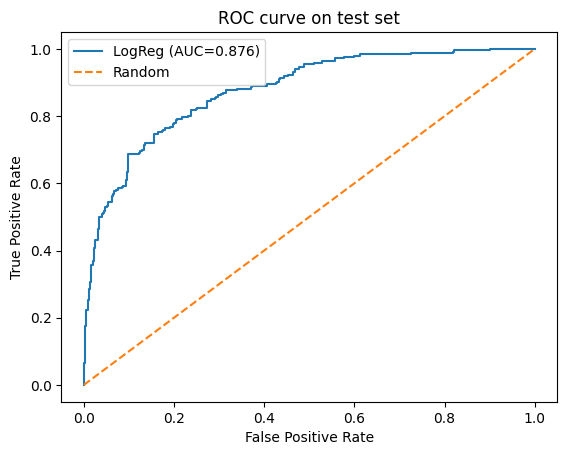

Saved to: C:\Users\DKornev\Desktop\ML\mirea-ml-course\homeworks\HW05\figures\roc_curve.png


In [11]:
# ROC-кривая 
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)

plt.figure()
plt.plot(fpr, tpr, label=f"LogReg (AUC={best_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve on test set")
plt.legend()

out_path = FIGURES_DIR / "roc_curve.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved to:", out_path.resolve())

In [12]:
# Сравнение моделей в компактном виде
comparison = pd.DataFrame([
    {"model": "Dummy (most_frequent)", "accuracy": acc_dummy, "roc_auc": auc_dummy},
    {"model": f"LogReg + scaler (best C={best_C})", "accuracy": best_acc, "roc_auc": best_auc, "avg_precision": avg_prec},
])

comparison

,model,accuracy,roc_auc,avg_precision
0,Dummy (most_frequent),0.590000,0.500000,NaN
1,LogReg + scaler (best C=100.0),0.801667,0.875649,0.839844


In [13]:
# Сохранить таблицы результатов в artifacts/
grid_df.to_csv(ARTIFACTS_DIR / "logreg_grid_results.csv", index=False)
comparison.to_csv(ARTIFACTS_DIR / "model_comparison.csv", index=False)

print("Saved artifacts to:", ARTIFACTS_DIR.resolve())

Saved artifacts to: C:\Users\DKornev\Desktop\ML\mirea-ml-course\homeworks\HW05\artifacts
